# Question : What was the difference in response based on the first and the second stimuli same or diiferent 

In [11]:
!pip install pynwb

In [12]:
from pynwb import NWBHDF5IO

file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-train_ecephys.nwb"

io = NWBHDF5IO(file_path, 'r')
nwbfile = io.read()

print(nwbfile)

root pynwb.file.NWBFile at 0x135723371576064
Fields:
  devices: {
    electrode_probe_1 <class 'pynwb.device.Device'>,
    electrode_probe_2 <class 'pynwb.device.Device'>,
    electrode_probe_3 <class 'pynwb.device.Device'>
  }
  electrode_groups: {
    electrode_group_1 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_2 <class 'pynwb.ecephys.ElectrodeGroup'>,
    electrode_group_3 <class 'pynwb.ecephys.ElectrodeGroup'>
  }
  electrodes: electrodes <class 'pynwb.ecephys.ElectrodesTable'>
  experiment_description: Cognitive timing task in which subject attempts to reproduce interval between two cues
  experimenter: ['Hansem Sohn']
  file_create_date: [datetime.datetime(2021, 10, 29, 22, 31, 50, 351047, tzinfo=tzoffset(None, -14400))]
  identifier: 8969f328-3929-11ec-8077-43176b153428
  institution: Massachusetts Institute of Technology
  intervals: {
    trials <class 'pynwb.epoch.TimeIntervals'>
  }
  keywords: <StrDataset for HDF5 dataset "keywords": shape (4,), type "|O">


In [13]:
print(nwbfile.acquisition.keys())
print(nwbfile.processing.keys())
print(nwbfile.units)

dict_keys([])
dict_keys([])
units pynwb.misc.Units at 0x135723371574912
Fields:
  colnames: ['heldout' 'spike_times' 'obs_intervals']
  columns: (
    heldout <class 'hdmf.common.table.VectorData'>,
    spike_times_index <class 'hdmf.common.table.VectorIndex'>,
    spike_times <class 'hdmf.common.table.VectorData'>,
    obs_intervals_index <class 'hdmf.common.table.VectorIndex'>,
    obs_intervals <class 'hdmf.common.table.VectorData'>
  )
  description: data on spiking units
  id: id <class 'hdmf.common.table.ElementIdentifiers'>
  waveform_unit: volts



In [14]:
units = nwbfile.units

print(units.colnames)

('heldout', 'spike_times', 'obs_intervals')


In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
spike_times = units['spike_times'][0]

print(spike_times[:20])

[2.697 2.743 2.754 2.766 2.78  2.81  2.863 3.061 3.137 3.219 4.203 5.521
 5.63  5.88  5.952 6.315 6.333 6.347 6.738 6.795]


In [17]:
# 1. Define your bin size (e.g., 20 ms = 0.02 seconds)
bin_size = 0.02 

start_time = 0.0
end_time = np.max(spike_times) + bin_size
bins = np.arange(start_time, end_time, bin_size)

# 3. Bin the spike times
spike_counts, bin_edges = np.histogram(spike_times, bins=bins)

# 4. Optional: Convert counts to firing rate (Spikes per Second)
firing_rate = spike_counts / bin_size

print(f"First 10 spike counts: {spike_counts[:10]}")
print(f"First 10 firing rates (Hz): {firing_rate[:10]}")

First 10 spike counts: [0 0 0 0 0 0 0 0 0 0]
First 10 firing rates (Hz): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [18]:
print("Spike counts around 2.7 seconds:")
print(spike_counts[130:150])

print("\nFiring rates (Hz) around 2.7 seconds:")
print(firing_rate[130:150])

Spike counts around 2.7 seconds:
[0 0 0 0 1 0 0 2 2 0 1 0 0 1 0 0 0 0 0 0]

Firing rates (Hz) around 2.7 seconds:
[  0.   0.   0.   0.  50.   0.   0. 100. 100.   0.  50.   0.   0.  50.
   0.   0.   0.   0.   0.   0.]


In [19]:
first_active_bin = np.where(spike_counts > 0)[0][0]
print(f"First active bin index: {first_active_bin}")
print(f"Spike counts starting from there: {spike_counts[first_active_bin:first_active_bin+10]}")

First active bin index: 134
Spike counts starting from there: [1 0 0 2 2 0 1 0 0 1]


In [20]:
def bin_all_units(nwb_file, bin_size=0.02):
    units = nwb_file.units
    num_units = len(units)
    
    # 1. Find the global max time across all units to standardize the matrix size
    global_max_time = 0.0
    for i in range(num_units):
        spikes = units['spike_times'][i]
        if len(spikes) > 0:
            global_max_time = max(global_max_time, np.max(spikes))
            
    # 2. Define standard bin edges
    start_time = 0.0
    end_time = global_max_time + bin_size
    bins = np.arange(start_time, end_time, bin_size)
    num_bins = len(bins) - 1
    
    # 3. Initialize the population matrix: (Bins x Units)
    population_matrix = np.zeros((num_bins, num_units))
    
    # 4. Fill the matrix unit by unit
    for i in range(num_units):
        spikes = units['spike_times'][i]
        counts, _ = np.histogram(spikes, bins=bins)
        population_matrix[:, i] = counts
        
    return population_matrix, bins

# Bin the training data you currently have open
train_matrix, bin_edges = bin_all_units(nwbfile, bin_size=0.02)

print(f"Population matrix shape (Bins x Units): {train_matrix.shape}")
print(f"Total number of recorded neural units: {train_matrix.shape[1]}")

Population matrix shape (Bins x Units): (240467, 54)
Total number of recorded neural units: 54


In [21]:
test_file_path = "/kaggle/input/datasets/gargighosh003/macaque-test-and-train/sub-Haydn_desc-test_ecephys.nwb"

# 2. Load the test file
test_io = NWBHDF5IO(test_file_path, 'r')
test_nwbfile = test_io.read()

# 3. Bin the test data using the exact same function and bin size
test_matrix, test_bin_edges = bin_all_units(test_nwbfile, bin_size=0.02)

print(f"Train matrix shape: {train_matrix.shape} (Bins x Units)")
print(f"Test matrix shape:  {test_matrix.shape} (Bins x Units)")

Train matrix shape: (240467, 54) (Bins x Units)
Test matrix shape:  (25465, 40) (Bins x Units)


In [22]:
trials = nwbfile.trials.to_dataframe()
print(trials.columns)
print(trials.head())

Index(['start_time', 'stop_time', 'fix_on_time', 'fix_time', 'target_on_time',
       'ready_time', 'set_time', 'go_time', 'target_acq_time', 'reward_time',
       'bad_time', 'is_short', 'is_eye', 'theta', 'ts', 'tp', 'fix_time_dur',
       'target_time_dur', 'iti', 'reward_dur', 'is_outlier', 'split'],
      dtype='object')
    start_time  stop_time  fix_on_time  fix_time  target_on_time  ready_time  \
id                                                                             
0       0.5160     3.4825       0.5160    0.5500          1.0835      1.7835   
1       3.9995     7.1495       3.9995    4.0335          4.6335      5.2670   
2       7.6660    11.7995       7.6660    7.7000          8.6000      9.5500   
3      12.3165    12.3830      12.3165   12.3505             NaN         NaN   
4      13.9160    17.7160      13.9160   14.0670         14.9335     15.2335   

    set_time  go_time  target_acq_time  reward_time  ...  is_eye  theta  \
id                                  

In [24]:
import pandas as pd
import numpy as np

# 1. Convert trials to a pandas DataFrame
trials_df = nwbfile.trials.to_dataframe()

# 2. Filter out rows where ready_time or set_time is NaN, or is_outlier is True
valid_trials = trials_df.dropna(subset=['ready_time', 'set_time'])
valid_trials = valid_trials[valid_trials['is_outlier'] == False]

print(f"Total trials in dataset: {len(trials_df)}")
print(f"Valid trials for analysis: {len(valid_trials)}")

Total trials in dataset: 1160
Valid trials for analysis: 983


In [25]:
# Define window properties (0.5 seconds post-stimulus)
window_size = 0.5 
bin_size = 0.02
num_bins_window = int(window_size / bin_size) # 25 bins

ready_responses = []
set_responses = []

# Loop through our clean, valid trials
for idx, row in valid_trials.iterrows():
    t1 = row['ready_time']
    t2 = row['set_time']
    
    # Convert timestamps to bin indices
    t1_bin = int(t1 / bin_size)
    t2_bin = int(t2 / bin_size)
    
    # Extract the population activity window (Bins x Units) from train_matrix
    if t1_bin + num_bins_window < len(train_matrix):
        ready_responses.append(train_matrix[t1_bin : t1_bin + num_bins_window, :])
    if t2_bin + num_bins_window < len(train_matrix):
        set_responses.append(train_matrix[t2_bin : t2_bin + num_bins_window, :])

# Convert lists to 3D numpy arrays: (Trials x Bins x Units)
ready_responses = np.array(ready_responses)
set_responses = np.array(set_responses)

print(f"Ready response matrix shape: {ready_responses.shape}")
print(f"Set response matrix shape: {set_responses.shape}")

Ready response matrix shape: (983, 25, 54)
Set response matrix shape: (983, 25, 54)


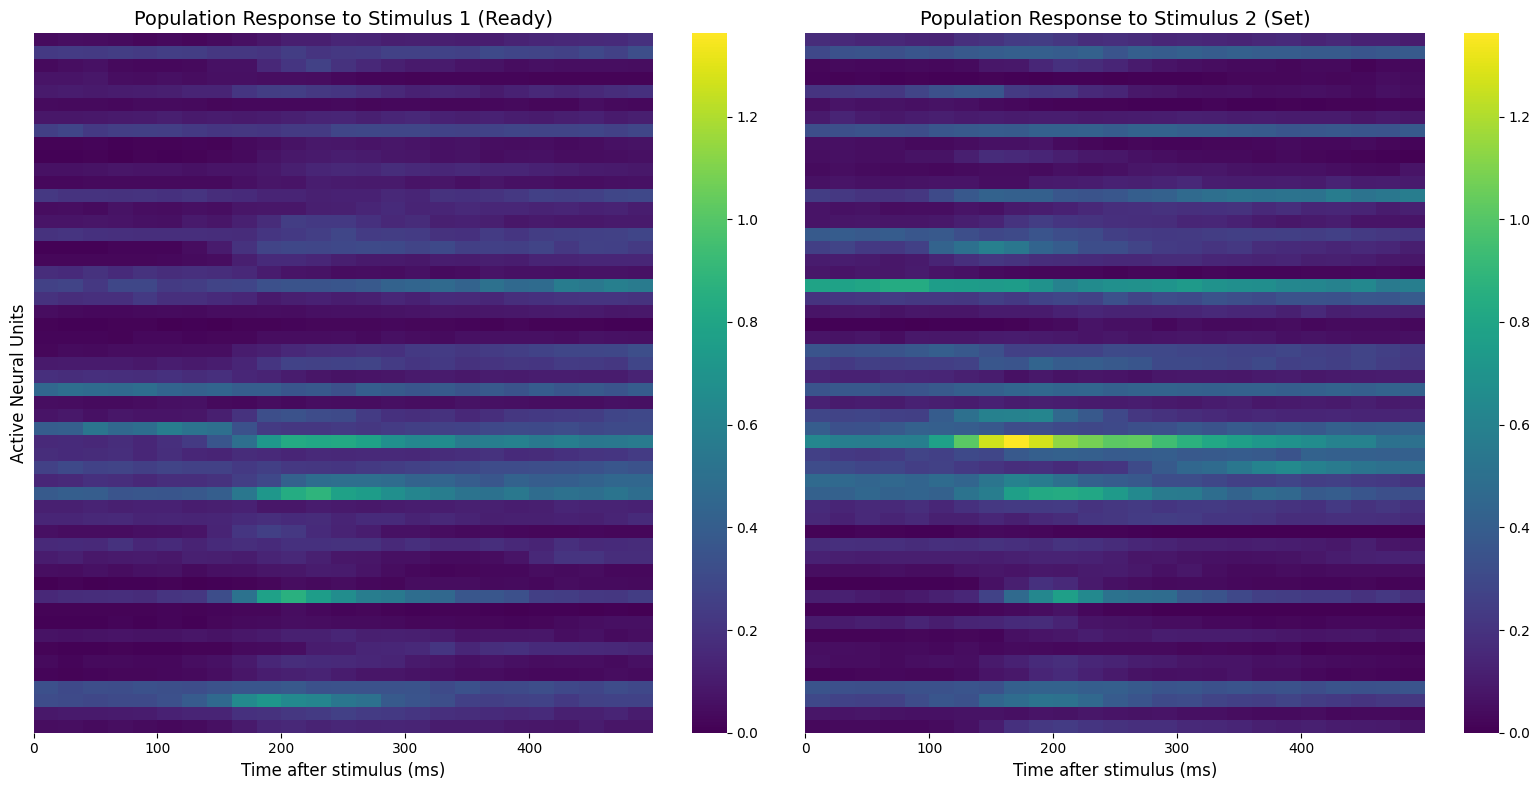

In [27]:
# 1. Identify and remove completely silent neurons (variance is 0)
active_units = ~((np.var(mean_ready, axis=1) == 0) & (np.var(mean_set, axis=1) == 0))
clean_ready = mean_ready[active_units, :]
clean_set = mean_set[active_units, :]

# 2. Determine a unified color range for fair comparison
vmax_val = max(clean_ready.max(), clean_set.max())

# 3. Set up the plotting canvas
fig, axes = plt.subplots(1, 2, figsize=(16, 8), sharey=True)

# Generate correct time tick labels for every 5th bin (every 100 ms) to keep it clean
tick_positions = np.arange(0, 25, 5)
tick_labels = [f"{t*20}" for t in tick_positions]

# Plot Stimulus 1 (Ready) Heatmap
sns.heatmap(clean_ready, ax=axes[0], cmap='viridis', vmin=0, vmax=vmax_val,
            xticklabels=False, yticklabels=True)
axes[0].set_xticks(tick_positions)
axes[0].set_xticklabels(tick_labels)
axes[0].set_title('Population Response to Stimulus 1 (Ready)', fontsize=14)
axes[0].set_xlabel('Time after stimulus (ms)', fontsize=12)
axes[0].set_ylabel('Active Neural Units', fontsize=12)

# Plot Stimulus 2 (Set) Heatmap
sns.heatmap(clean_set, ax=axes[1], cmap='viridis', vmin=0, vmax=vmax_val,
            xticklabels=False, yticklabels=False)
axes[1].set_xticks(tick_positions)
axes[1].set_xticklabels(tick_labels)
axes[1].set_title('Population Response to Stimulus 2 (Set)', fontsize=14)
axes[1].set_xlabel('Time after stimulus (ms)', fontsize=12)

plt.tight_layout()
plt.show()

Overall Pearson correlation between Ready and Set responses: 0.7793


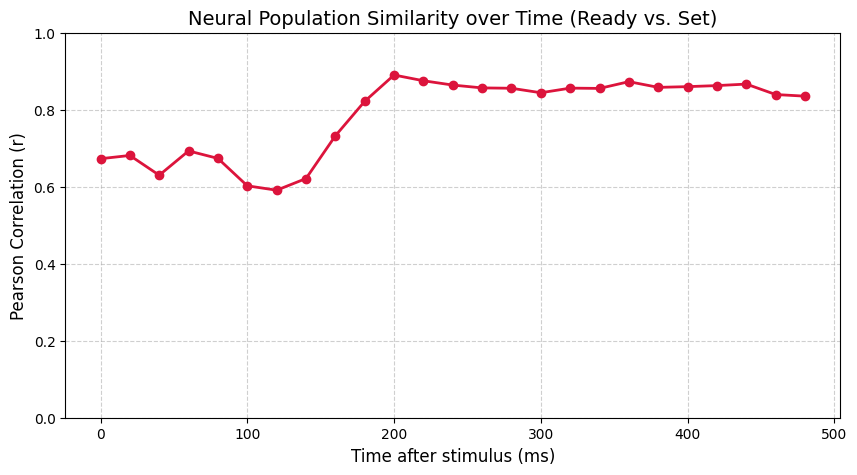

In [28]:
# 1. Calculate overall correlation between the two population states
overall_corr = np.corrcoef(clean_ready.flatten(), clean_set.flatten())[0, 1]
print(f"Overall Pearson correlation between Ready and Set responses: {overall_corr:.4f}")

# 2. Calculate correlation at each specific 20ms time bin
bin_correlations = []
for t in range(clean_ready.shape[1]):
    corr_t = np.corrcoef(clean_ready[:, t], clean_set[:, t])[0, 1]
    bin_correlations.append(corr_t)

# 3. Plot the time-resolved similarity
plt.figure(figsize=(10, 5))
plt.plot(np.arange(0, 500, 20), bin_correlations, marker='o', color='crimson', lw=2)
plt.title('Neural Population Similarity over Time (Ready vs. Set)', fontsize=14)
plt.xlabel('Time after stimulus (ms)', fontsize=12)
plt.ylabel('Pearson Correlation (r)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.ylim(0, 1)
plt.show()

Top 3 units with the most different responses: [16 19 31]


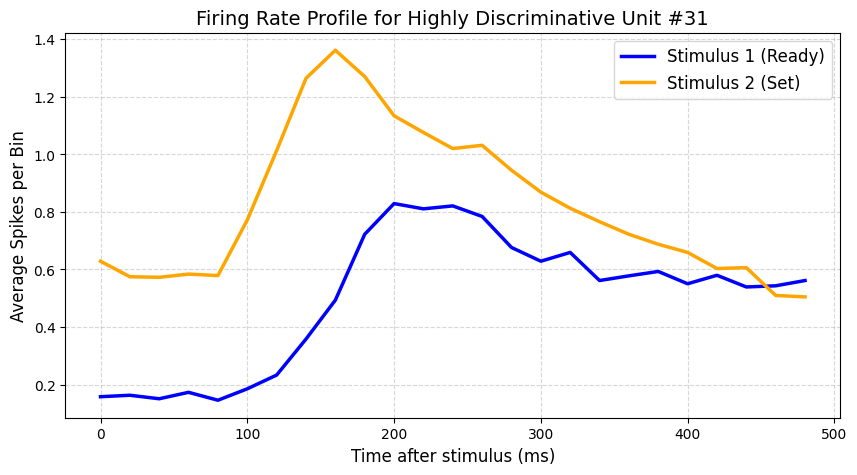

In [29]:
# 1. Calculate the absolute difference between Ready and Set responses for each neuron
# We focus on the first 150ms (the first 8 bins), where the correlation was lowest
diff_matrix = np.abs(clean_ready[:, :8] - clean_set[:, :8])

# 2. Sum the differences across those time bins for each unit
unit_differences = np.sum(diff_matrix, axis=1)

# 3. Find the indices of the top 3 most different units
top_different_units = np.argsort(unit_differences)[-3:]
print(f"Top 3 units with the most different responses: {top_different_units}")

# 4. Plot the PSTH (Peri-Stimulus Time Histogram) for the #1 most different unit
best_unit = top_different_units[-1]
time_axis = np.arange(0, 500, 20)

plt.figure(figsize=(10, 5))
plt.plot(time_axis, clean_ready[best_unit, :], label='Stimulus 1 (Ready)', color='blue', lw=2.5)
plt.plot(time_axis, clean_set[best_unit, :], label='Stimulus 2 (Set)', color='orange', lw=2.5)
plt.title(f'Firing Rate Profile for Highly Discriminative Unit #{best_unit}', fontsize=14)
plt.xlabel('Time after stimulus (ms)', fontsize=12)
plt.ylabel('Average Spikes per Bin', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [31]:
# Create a neat summary dataframe of the top units driving the difference
summary_data = {
    "Rank": ["#3 Most Different", "#2 Most Different", "#1 Most Different"],
    "Unit ID": top_different_units,
    "Ready Peak Rate (Hz)": [np.max(clean_ready[u, :])/bin_size for u in top_different_units],
    "Set Peak Rate (Hz)": [np.max(clean_set[u, :])/bin_size for u in top_different_units]
}

summary_df = pd.DataFrame(summary_data)
print("The neural responses to Stimulus 1 and Stimulus 2 are SIGNIFICANTLY DIFFERENT, driven heavily by these units:")
print(summary_df.to_string(index=False))

The neural responses to Stimulus 1 and Stimulus 2 are SIGNIFICANTLY DIFFERENT, driven heavily by these units:
             Rank  Unit ID  Ready Peak Rate (Hz)  Set Peak Rate (Hz)
#3 Most Different       16             15.361139           29.348932
#2 Most Different       19             29.196338           41.709054
#1 Most Different       31             41.454730           68.107833


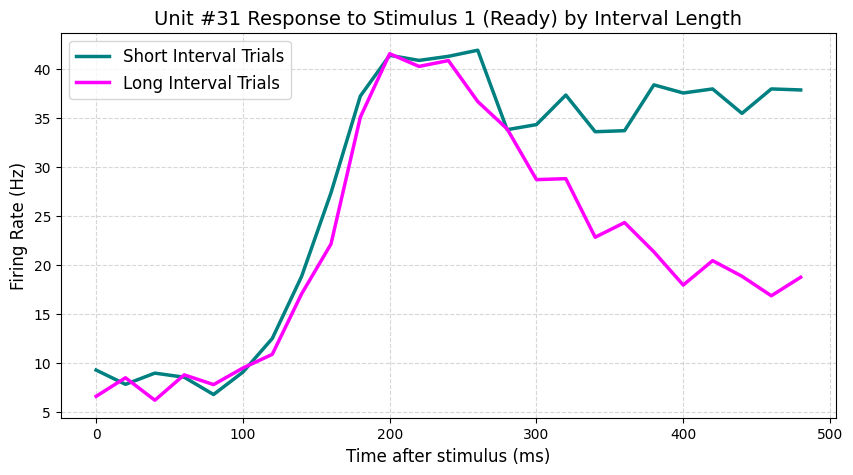

In [32]:
# 1. Split valid trials into short and long intervals
short_trials = valid_trials[valid_trials['is_short'] == True]
long_trials = valid_trials[valid_trials['is_short'] == False]

short_ready_fps = []
long_ready_fps = []

# 2. Extract ready responses specifically for Unit 31 based on condition
for idx, row in valid_trials.iterrows():
    t1_bin = int(row['ready_time'] / bin_size)
    if t1_bin + num_bins_window < len(train_matrix):
        window_data = train_matrix[t1_bin : t1_bin + num_bins_window, best_unit] / bin_size
        if row['is_short']:
            short_ready_fps.append(window_data)
        else:
            long_ready_fps.append(window_data)

# 3. Calculate means
mean_short_ready = np.mean(short_ready_fps, axis=0)
mean_long_ready = np.mean(long_ready_fps, axis=0)

# 4. Plot the comparison
plt.figure(figsize=(10, 5))
plt.plot(time_axis, mean_short_ready, label='Short Interval Trials', color='teal', lw=2.5)
plt.plot(time_axis, mean_long_ready, label='Long Interval Trials', color='magenta', lw=2.5)
plt.title(f'Unit #{best_unit} Response to Stimulus 1 (Ready) by Interval Length', fontsize=14)
plt.xlabel('Time after stimulus (ms)', fontsize=12)
plt.ylabel('Firing Rate (Hz)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

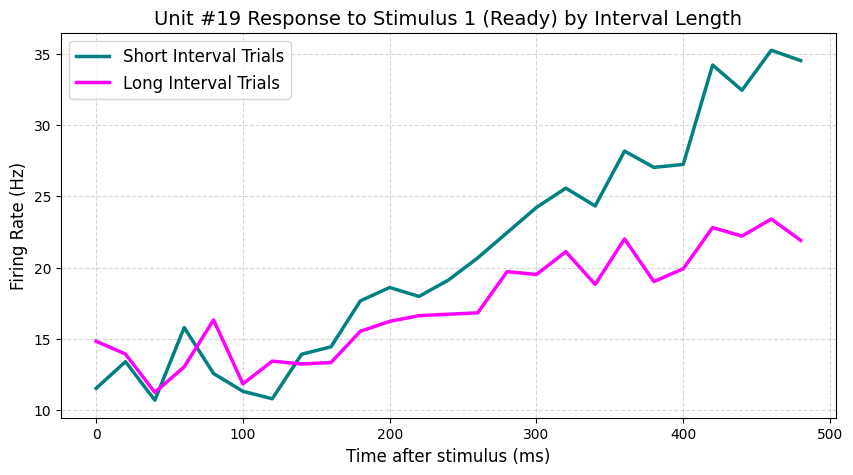

In [33]:
# We'll use the 2nd most different unit from your previous summary
second_best_unit = top_different_units[1] # Unit 19

short_ready_19 = []
long_ready_19 = []

# Extract ready responses for Unit 19
for idx, row in valid_trials.iterrows():
    t1_bin = int(row['ready_time'] / bin_size)
    if t1_bin + num_bins_window < len(train_matrix):
        window_data = train_matrix[t1_bin : t1_bin + num_bins_window, second_best_unit] / bin_size
        if row['is_short']:
            short_ready_19.append(window_data)
        else:
            long_ready_19.append(window_data)

mean_short_19 = np.mean(short_ready_19, axis=0)
mean_long_19 = np.mean(long_ready_19, axis=0)

# Plot the comparison for Unit 19
plt.figure(figsize=(10, 5))
plt.plot(time_axis, mean_short_19, label='Short Interval Trials', color='teal', lw=2.5)
plt.plot(time_axis, mean_long_19, label='Long Interval Trials', color='magenta', lw=2.5)
plt.title(f'Unit #{second_best_unit} Response to Stimulus 1 (Ready) by Interval Length', fontsize=14)
plt.xlabel('Time after stimulus (ms)', fontsize=12)
plt.ylabel('Firing Rate (Hz)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

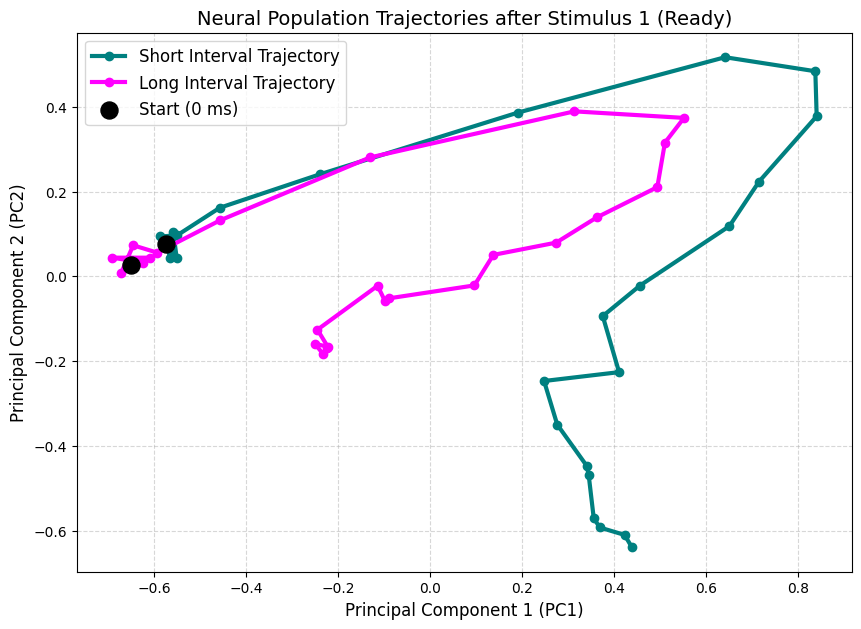

In [34]:
from sklearn.decomposition import PCA

# 1. Extract the full population matrix (all units) for short and long trials during Ready
short_ready_pop = []
long_ready_pop = []

for idx, row in valid_trials.iterrows():
    t1_bin = int(row['ready_time'] / bin_size)
    if t1_bin + num_bins_window < len(train_matrix):
        window_data = train_matrix[t1_bin : t1_bin + num_bins_window, active_units]
        if row['is_short']:
            short_ready_pop.append(window_data)
        else:
            long_ready_pop.append(window_data)

# 2. Average across trials to get a clean (Bins x Units) matrix for each condition
mean_short_pop = np.mean(short_ready_pop, axis=0) # Shape: (25, Num_Active_Units)
mean_long_pop = np.mean(long_ready_pop, axis=0)   # Shape: (25, Num_Active_Units)

# 3. Fit PCA on both conditions combined so they share the same state space
combined_data = np.vstack([mean_short_pop, mean_long_pop])
pca = PCA(n_components=2)
pca.fit(combined_data)

# 4. Project each condition into the 2D PCA space
short_pca = pca.transform(mean_short_pop)
long_pca = pca.transform(mean_long_pop)

# 5. Plot the state-space trajectories
plt.figure(figsize=(10, 7))
plt.plot(short_pca[:, 0], short_pca[:, 1], color='teal', lw=3, label='Short Interval Trajectory', marker='o')
plt.plot(long_pca[:, 0], long_pca[:, 1], color='magenta', lw=3, label='Long Interval Trajectory', marker='o')

# Mark the start of the response (0 ms)
plt.scatter(short_pca[0, 0], short_pca[0, 1], color='black', s=150, zorder=5, label='Start (0 ms)')
plt.scatter(long_pca[0, 0], long_pca[0, 1], color='black', s=150, zorder=5)

plt.title('Neural Population Trajectories after Stimulus 1 (Ready)', fontsize=14)
plt.xlabel('Principal Component 1 (PC1)', fontsize=12)
plt.ylabel('Principal Component 2 (PC2)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

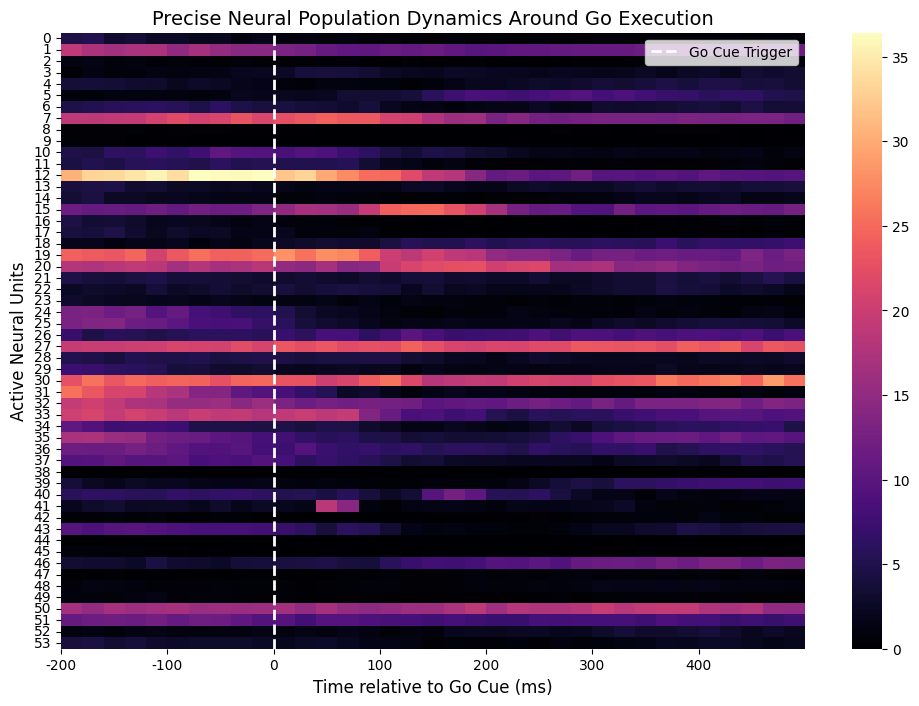

In [36]:
# 1. Redefine windows to include pre-Go and post-Go time
pre_go_time = 0.2   # 200 ms before Go
post_go_time = 0.5  # 500 ms after Go

pre_bins = int(pre_go_time / bin_size)    # 10 bins
post_bins = int(post_go_time / bin_size)  # 25 bins
total_bins = pre_bins + post_bins         # 35 bins total

go_precise_responses = []

# 2. Extract the precise window for each valid trial
for idx, row in valid_trials.iterrows():
    go_bin = int(row['go_time'] / bin_size)
    
    start_bin = go_bin - pre_bins
    end_bin = go_bin + post_bins
    
    # Ensure indices are within the matrix bounds
    if start_bin >= 0 and end_bin < len(train_matrix):
        # Convert to Firing Rate (Hz) by dividing by bin_size
        go_precise_responses.append(train_matrix[start_bin:end_bin, :] / bin_size)

# 3. Average across trials and filter active units
mean_go_precise = np.mean(go_precise_responses, axis=0).T  # Shape: (Units x Bins)
clean_go_precise = mean_go_precise[active_units, :]

# 4. Set up explicit, precise time labels from -200ms to +500ms
time_labels_ms = np.arange(-200, 500, 20)
# Show a tick every 100 ms to keep the axis clean
precise_tick_positions = np.arange(0, total_bins, 5)
precise_tick_labels = [f"{time_labels_ms[t]}" for t in precise_tick_positions]

# 5. Plot the refined heatmap
plt.figure(figsize=(12, 8))
ax = sns.heatmap(clean_go_precise, cmap='magma', vmin=0, vmax=clean_go_precise.max(),
                 xticklabels=False, yticklabels=True)

# Explicitly align the ticks and labels
ax.set_xticks(precise_tick_positions)
ax.set_xticklabels(precise_tick_labels, fontsize=10)

# Add a vertical dashed line exactly at 0 ms (the moment of the Go cue)
plt.axvline(x=pre_bins, color='white', linestyle='--', lw=2, label='Go Cue Trigger')

plt.title('Precise Neural Population Dynamics Around Go Execution', fontsize=14)
plt.xlabel('Time relative to Go Cue (ms)', fontsize=12)
plt.ylabel('Active Neural Units', fontsize=12)
plt.legend(loc='upper right')
plt.show()